## Problem Statement

This tutorial takes a practical and coding-focused approach. We'll learn gradient boosting by applying it to a real-world dataset from the [Rossmann Store Sales](https://www.kaggle.com/c/rossmann-store-sales) competition on Kaggle:

> Rossmann operates over 3,000 drug stores in 7 European countries. Currently, Rossmann store managers are tasked with predicting their daily sales for up to six weeks in advance. Store sales are influenced by many factors, including promotions, competition, school and state holidays, seasonality, and locality.
>
>
> With thousands of individual managers predicting sales based on their unique circumstances, the accuracy of results can be quite varied. You are provided with historical sales data for 1,115 Rossmann stores. The task is to forecast the "Sales" column for the test set. Note that some stores in the dataset were temporarily closed for refurbishment.
>
> View and download the data here: https://www.kaggle.com/c/rossmann-store-sales/data

In [1]:
import pandas as pd
import numpy as np

!! Load datasets into Pandas DataFrame

In [2]:
ross_df = pd.read_csv('/content/train.csv',low_memory=False)
store_df = pd.read_csv('/content/store.csv')
test_df = pd.read_csv('/content/test.csv')
submission_df = pd.read_csv('/content/sample_submission.csv')

In [3]:
ross_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [4]:
submission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Id      41088 non-null  int64
 1   Sales   41088 non-null  int64
dtypes: int64(2)
memory usage: 642.1 KB


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB


In [6]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [7]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_test_df = test_df.merge(store_df, how='left', on= 'Store')

In [8]:
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [9]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

<Axes: xlabel='Store', ylabel='Sales'>

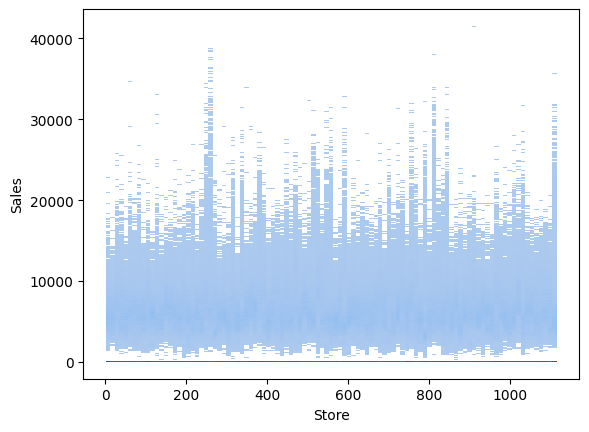

In [10]:
sns.histplot(data=merged_df, x='Store', y='Sales', )

<Axes: xlabel='Sales', ylabel='Count'>

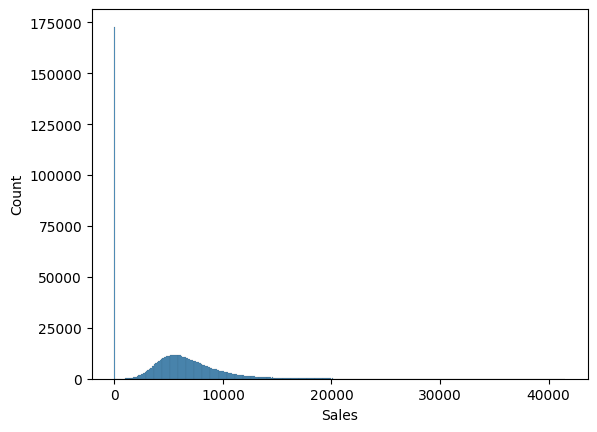

In [11]:
sns.histplot(data=merged_df, x='Sales')

In [12]:
ross_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

## **Preprocessing and Feature Engineering**

In [13]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

### **Date**

In [14]:
def split_date(df):
  df['Date'] = pd.to_datetime(df['Date'])
  df['Day'] = df.Date.dt.day
  df['Month'] = df.Date.dt.month
  df['Year'] = df.Date.dt.year
  df['WeekOfYear'] = df.Date.dt.isocalendar().week

In [15]:
split_date(merged_df)
split_date(merged_test_df)

In [16]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,NaN,31,7,2015,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",31,7,2015,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",31,7,2015,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,31,7,2015,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,NaN,31,7,2015,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,...,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",1,1,2013,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,...,4.0,2006.0,0,NaN,NaN,NaN,1,1,2013,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,...,NaN,NaN,0,NaN,NaN,NaN,1,1,2013,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,...,NaN,NaN,0,NaN,NaN,NaN,1,1,2013,1


In [17]:
merged_df[merged_df.Open == 0].Sales.value_counts()

,count
Sales,
0,172817


In [18]:
merged_df = merged_df[merged_df.Open == 1].copy()

In [19]:
merged_df.sample(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year,WeekOfYear
790502,753,2,2013-07-23,6681,579,1,0,0,1,d,...,11.0,2012.0,1,35.0,2010.0,"Mar,Jun,Sept,Dec",23,7,2013,30
288298,589,4,2014-11-06,6664,647,1,1,0,0,a,...,NaN,NaN,1,18.0,2013.0,"Feb,May,Aug,Nov",6,11,2014,45
57978,1114,3,2015-06-10,19162,3086,1,0,0,0,a,...,NaN,NaN,0,NaN,NaN,NaN,10,6,2015,24
123418,769,7,2015-04-12,12460,3147,1,0,0,0,b,...,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",12,4,2015,15
254710,680,5,2014-12-12,6419,977,1,0,0,0,c,...,NaN,NaN,1,35.0,2012.0,"Mar,Jun,Sept,Dec",12,12,2014,50
110999,615,4,2015-04-23,7471,1059,1,0,0,0,d,...,8.0,2007.0,0,NaN,NaN,NaN,23,4,2015,17
828391,732,3,2013-06-19,5960,690,1,1,0,0,a,...,NaN,NaN,0,NaN,NaN,NaN,19,6,2013,25
559085,141,6,2014-02-15,4555,554,1,0,0,0,c,...,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec",15,2,2014,7
763291,302,5,2013-08-16,3737,328,1,1,0,1,d,...,12.0,2007.0,1,9.0,2011.0,"Mar,Jun,Sept,Dec",16,8,2013,33
471701,842,1,2014-05-05,20737,1202,1,1,0,0,d,...,11.0,2007.0,0,NaN,NaN,NaN,5,5,2014,19


### Competition

Next, we can use the columns `CompetitionOpenSince[Month/Year]` columns from `store_df` to compute the number of months for which a competitor has been open near the store.

In [20]:
def comp_months(df):
  df['CompetitionOpen'] = 12 * (df.Year - df.CompetitionOpenSinceYear) + (df.Month - df.CompetitionOpenSinceMonth)
  df['CompetitionOpen'] = df['CompetitionOpen'].map(lambda x: 0 if x<0 else x).fillna(0)

In [21]:
comp_months(merged_df)
comp_months(merged_test_df)

In [22]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year,WeekOfYear,CompetitionOpen
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,NaN,NaN,31,7,2015,31,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",31,7,2015,31,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",31,7,2015,31,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,NaN,NaN,31,7,2015,31,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,NaN,NaN,31,7,2015,31,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,2006.0,0,NaN,NaN,NaN,1,1,2013,1,76.0
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,1999.0,0,NaN,NaN,NaN,1,1,2013,1,159.0
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",1,1,2013,1,0.0
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,NaN,0,NaN,NaN,NaN,1,1,2013,1,0.0


In [23]:
merged_df[['Date', 'CompetitionDistance', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpen']].sample(20)

,Date,CompetitionDistance,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpen
97284,2015-05-05,18640.0,2013.0,9.0,20.0
902581,2013-04-13,3150.0,NaN,NaN,0.0
229636,2015-01-07,190.0,2012.0,9.0,28.0
269623,2014-11-26,9910.0,NaN,NaN,0.0
748455,2013-08-30,90.0,NaN,NaN,0.0
978914,2013-02-04,1190.0,2013.0,9.0,0.0
923838,2013-03-25,6540.0,2007.0,12.0,63.0
523045,2014-03-20,170.0,2012.0,9.0,18.0
300644,2014-10-24,16210.0,2010.0,11.0,47.0
926311,2013-03-23,1070.0,2010.0,8.0,31.0


### Additional Promotion

We can also add some additional columns to indicate how long a store has been running `Promo2` and whether a new round of `Promo2` starts in the current month.

In [24]:
def check_promo_month(row):
  month2str = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7: 'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
  try:
    months = (row['PromoInterval'] or '').split(',')
    if row['Promo2Open'] and month2str[row['Month']] in months:
      return 1
    else:
      return 0
  except Exception:
      return 0

def promo_cols(df):
    # Months since Promo2 was open
    df['Promo2Open'] = 12 * (df.Year - df.Promo2SinceYear) + (df.WeekOfYear - df.Promo2SinceWeek)*7/30.5
    df['Promo2Open'] = df['Promo2Open'].map(lambda x: 0 if x < 0 else x).fillna(0) * df['Promo2']
    # Whether a new round of promotions was started in the current month
    df['IsPromo2Month'] = df.apply(check_promo_month, axis=1) * df['Promo2']


In [25]:
promo_cols(merged_df)

In [26]:
promo_cols(merged_test_df)

In [27]:
merged_df[['Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval', 'Promo2Open', 'IsPromo2Month']].sample(20)

,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,Promo2Open,IsPromo2Month
402012,2014-07-07,1,2011.0,14.0,"Jan,Apr,Jul,Oct",39.213115,1
442013,2014-05-31,0,NaN,NaN,NaN,0.000000,0
5330,2015-07-27,0,NaN,NaN,NaN,0.000000,0
336816,2014-09-15,0,NaN,NaN,NaN,0.000000,0
327840,2014-09-25,0,NaN,NaN,NaN,0.000000,0
300626,2014-10-24,0,NaN,NaN,NaN,0.000000,0
110482,2015-04-23,1,2012.0,1.0,"Jan,Apr,Jul,Oct",39.672131,1
292675,2014-11-01,0,NaN,NaN,NaN,0.000000,0
359358,2014-08-22,1,2013.0,18.0,"Feb,May,Aug,Nov",15.672131,1
680448,2013-10-30,1,2010.0,13.0,"Jan,Apr,Jul,Oct",43.114754,1


In [28]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year,WeekOfYear,CompetitionOpen,Promo2Open,IsPromo2Month
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,NaN,NaN,NaN,31,7,2015,31,82.0,0.000000,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",31,7,2015,31,92.0,64.131148,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14.0,2011.0,"Jan,Apr,Jul,Oct",31,7,2015,31,103.0,51.901639,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,NaN,NaN,NaN,31,7,2015,31,70.0,0.000000,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,NaN,NaN,NaN,31,7,2015,31,3.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,NaN,NaN,NaN,1,1,2013,1,76.0,0.000000,0
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,NaN,NaN,NaN,1,1,2013,1,159.0,0.000000,0
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,48.0,2012.0,"Jan,Apr,Jul,Oct",1,1,2013,1,0.0,1.213115,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,NaN,NaN,NaN,1,1,2013,1,0.0,0.000000,0


In [29]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Day', 'Month', 'Year',
       'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month'],
      dtype='object')

In [30]:
input_cols = ['Store', 'DayOfWeek', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'Promo2', 'Day', 'Month', 'Year',
       'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month']
target_col = ['Sales']

In [31]:
inputs = merged_df[input_cols].copy()
targets = merged_df[target_col].copy()

In [32]:
test_inputs = merged_test_df[input_cols].copy()

In [33]:
inputs

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Day,Month,Year,WeekOfYear,CompetitionOpen,Promo2Open,IsPromo2Month
0,1,5,1,0,1,c,a,1270.0,0,31,7,2015,31,82.0,0.000000,0
1,2,5,1,0,1,a,a,570.0,1,31,7,2015,31,92.0,64.131148,1
2,3,5,1,0,1,a,a,14130.0,1,31,7,2015,31,103.0,51.901639,1
3,4,5,1,0,1,c,c,620.0,0,31,7,2015,31,70.0,0.000000,0
4,5,5,1,0,1,a,a,29910.0,0,31,7,2015,31,3.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,0,a,1,b,a,150.0,0,1,1,2013,1,76.0,0.000000,0
1016827,733,2,0,a,1,b,b,860.0,0,1,1,2013,1,159.0,0.000000,0
1016863,769,2,0,a,1,b,b,840.0,1,1,1,2013,1,0.0,1.213115,1
1017042,948,2,0,a,1,b,b,1430.0,0,1,1,2013,1,0.0,0.000000,0


In [34]:
targets

,Sales
0,5263
1,6064
2,8314
3,13995
4,4822
...,...
1016776,3375
1016827,10765
1016863,5035
1017042,4491


In [35]:
test_inputs

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Day,Month,Year,WeekOfYear,CompetitionOpen,Promo2Open,IsPromo2Month
0,1,4,1,0,0,c,a,1270.0,0,17,9,2015,38,84.0,0.000000,0
1,3,4,1,0,0,a,a,14130.0,1,17,9,2015,38,105.0,53.508197,0
2,7,4,1,0,0,a,c,24000.0,0,17,9,2015,38,29.0,0.000000,0
3,8,4,1,0,0,a,a,7520.0,0,17,9,2015,38,11.0,0.000000,0
4,9,4,1,0,0,a,c,2030.0,0,17,9,2015,38,181.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,1111,6,0,0,0,a,a,1900.0,1,1,8,2015,31,14.0,24.000000,0
41084,1112,6,0,0,0,c,c,1880.0,0,1,8,2015,31,112.0,0.000000,0
41085,1113,6,0,0,0,a,c,9260.0,0,1,8,2015,31,0.0,0.000000,0
41086,1114,6,0,0,0,a,c,870.0,0,1,8,2015,31,0.0,0.000000,0


In [36]:
numeric_cols = ['Store', 'Promo','SchoolHoliday',
       'CompetitionDistance', 'Promo2', 'Day', 'Month', 'Year',
       'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month']
categorial_cols = ['DayOfWeek','StateHoliday', 'StoreType', 'Assortment']

In [37]:
from sklearn.impute import SimpleImputer

In [38]:
inputs[numeric_cols].isna().sum()

,0
Store,0
Promo,0
SchoolHoliday,0
CompetitionDistance,2186
Promo2,0
Day,0
Month,0
Year,0
WeekOfYear,0
CompetitionOpen,0


In [39]:
test_inputs[numeric_cols].isna().sum()

,0
Store,0
Promo,0
SchoolHoliday,0
CompetitionDistance,96
Promo2,0
Day,0
Month,0
Year,0
WeekOfYear,0
CompetitionOpen,0


In [40]:
max_distance = inputs.CompetitionDistance.max()
max_distance

75860.0

In [41]:
inputs['CompetitionDistance'].fillna(max_distance*2, inplace=True)
test_inputs['CompetitionDistance'].fillna(max_distance*2, inplace=True)

/tmp/ipython-input-733699737.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inputs['CompetitionDistance'].fillna(max_distance*2, inplace=True)
/tmp/ipython-input-733699737.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [42]:
from sklearn.preprocessing import MinMaxScaler

In [43]:
scaler = MinMaxScaler().fit(inputs[numeric_cols])

In [44]:
inputs[numeric_cols] = scaler.transform(inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [45]:
from sklearn.preprocessing import OneHotEncoder

In [46]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(inputs[categorial_cols])
encoded_cols = list(encoder.get_feature_names_out(categorial_cols))

In [47]:
inputs[encoded_cols] = encoder.transform(inputs[categorial_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorial_cols])

In [48]:
X = inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [49]:
X

,Store,Promo,SchoolHoliday,CompetitionDistance,Promo2,Day,Month,Year,WeekOfYear,CompetitionOpen,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
0,0.000000,1.0,1.0,0.008240,0.0,1.0,0.545455,1.0,0.588235,0.059163,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.000898,1.0,1.0,0.003626,1.0,1.0,0.545455,1.0,0.588235,0.066378,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.001795,1.0,1.0,0.093013,1.0,1.0,0.545455,1.0,0.588235,0.074315,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.002693,1.0,1.0,0.003955,0.0,1.0,0.545455,1.0,0.588235,0.050505,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.003591,1.0,1.0,0.197034,0.0,1.0,0.545455,1.0,0.588235,0.002165,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,0.611311,0.0,1.0,0.000857,0.0,0.0,0.000000,0.0,0.000000,0.054834,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016827,0.657092,0.0,1.0,0.005537,0.0,0.0,0.000000,0.0,0.000000,0.114719,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016863,0.689408,0.0,1.0,0.005405,1.0,0.0,0.000000,0.0,0.000000,0.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1017042,0.850090,0.0,1.0,0.009295,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Gradient Boosting

We're now ready to train our gradient boosting machine (GBM) model. Here's how a GBM model works:

1. The average value of the target column and uses as an initial prediction every input.
2. The residuals (difference) of the predictions with the targets are computed.
3. A decision tree of limited depth is trained to **predict just the residuals** for each input.
4. Predictions from the decision tree are scaled using a parameter called the learning rate (this prevents overfitting)
5. Scaled predictions fro the tree are added to the previous predictions to obtain the new and improved predictions.
6. Steps 2 to 5 are repeated to create new decision trees, each of which is trained to predict just the residuals from the previous prediction.

The term "gradient" refers to the fact that each decision tree is trained with the purpose of reducing the loss from the previous iteration (similar to gradient descent). The term "boosting" refers the general technique of training new models to improve the results of an existing model.

For a mathematical explanation of gradient boosting, check out the following resources:

- [XGBoost Documentation](https://xgboost.readthedocs.io/en/latest/tutorials/model.html)
Here's a visual representation of gradient boosting:

![](https://miro.medium.com/max/560/1*85QHtH-49U7ozPpmA5cAaw.png)


### Training
To Train GBM, we can use `XGBRegressor` class from the `XGBoost` library.

In [50]:
from xgboost import XGBRegressor

In [51]:
model = XGBRegressor(random_state=42, n_jobs =-1, n_estimators = 20, max_depth = 4)

In [52]:
%time
model.fit(X, targets)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 7.39 µs


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=-1, num_parallel_tree=None, ...)

Predictions

In [53]:
preds = model.predict(X)
preds

array([ 8131.5044,  7312.157 ,  8846.703 , ...,  7076.3633,  7685.781 ,
       10194.288 ], dtype=float32)

Evaluation

In [54]:
from sklearn.metrics import mean_squared_error

def rmse(a,b):
  return np.sqrt(mean_squared_error(a, b,))

In [55]:
rmse(preds, targets)

np.float64(2366.7913934269745)

In [56]:
merged_df.Sales.min(),merged_df.Sales.max()

(0, 41551)

(array([7.560e+02, 4.361e+03, 3.139e+03, 1.173e+03, 3.560e+02, 1.380e+02,
        5.100e+01, 1.900e+01, 2.000e+00, 5.000e+00]),
 array([  552. ,  3480.2,  6408.4,  9336.6, 12264.8, 15193. , 18121.2,
        21049.4, 23977.6, 26905.8, 29834. ]),
 <BarContainer object of 10 artists>)

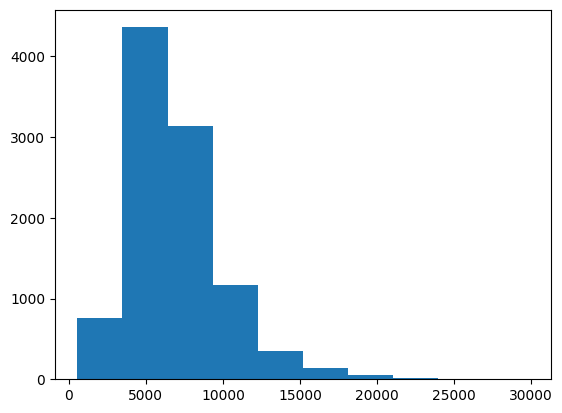

In [57]:
plt.hist(merged_df.Sales.sample(10000))

### Visulization
we can visulize individual trees using `plot_tree`

In [58]:
from xgboost import plot_tree
from matplotlib.pylab import rcParams
%matplotlib inline

rcParams['figure.figsize'] = 30,30

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


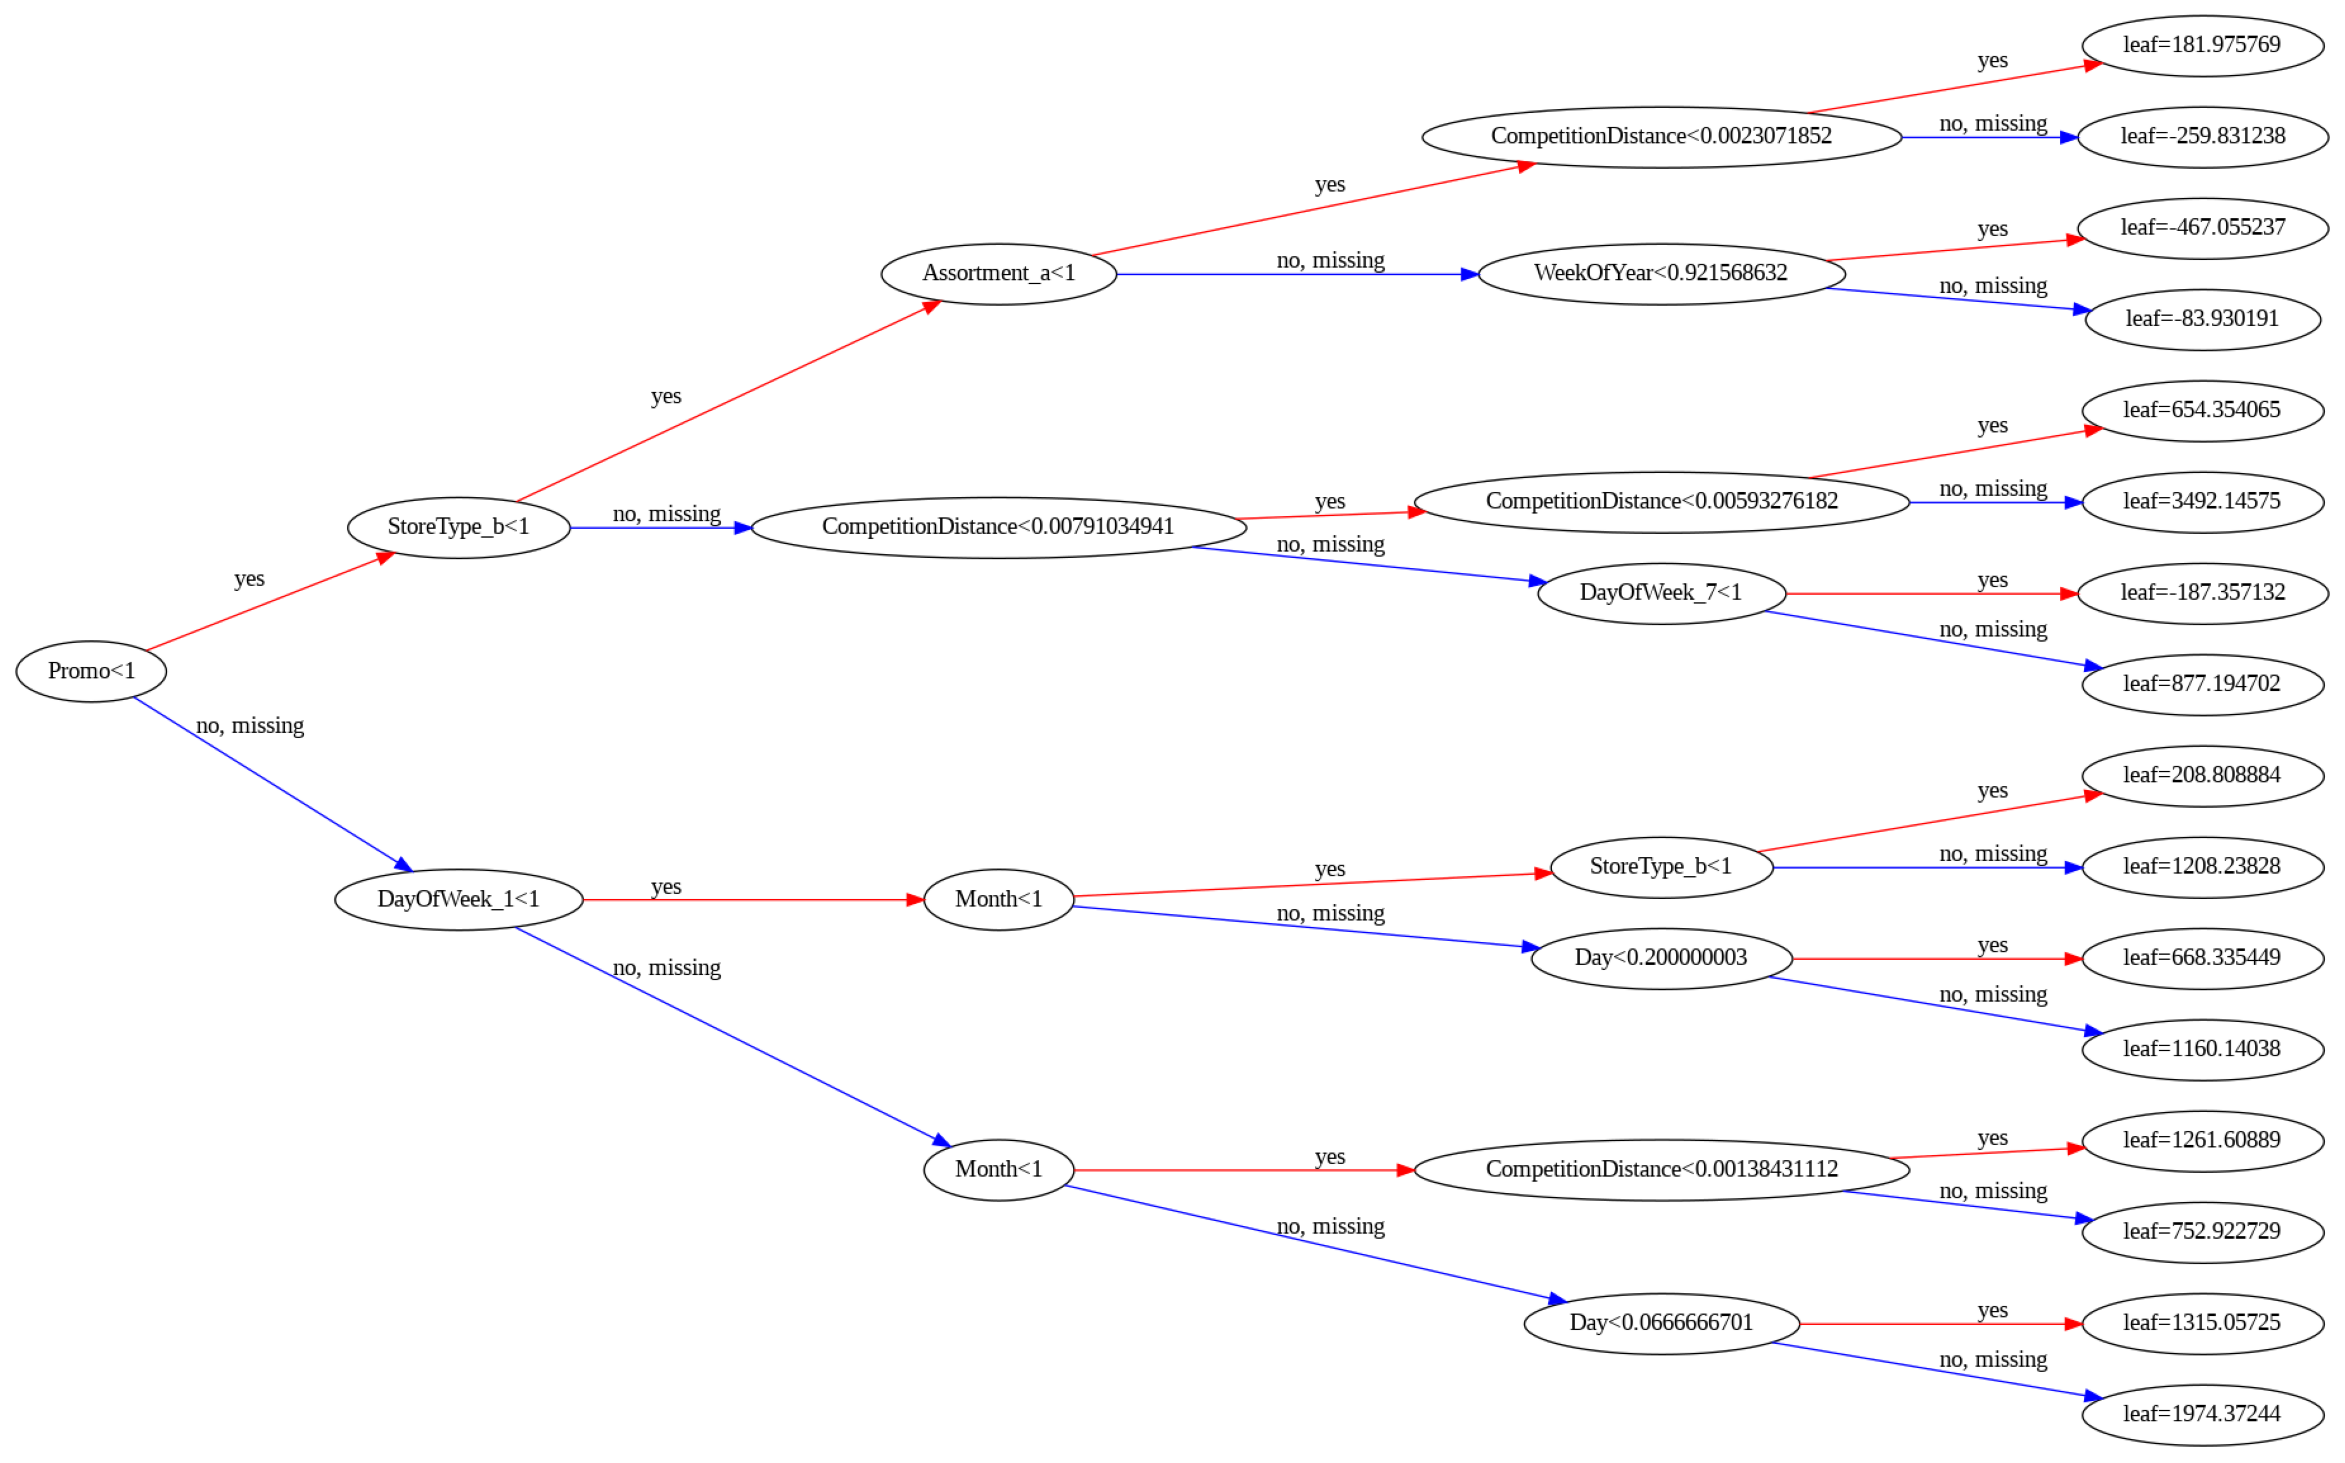

In [59]:
plot_tree(model,rankdir='LR',num_trees=0);

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

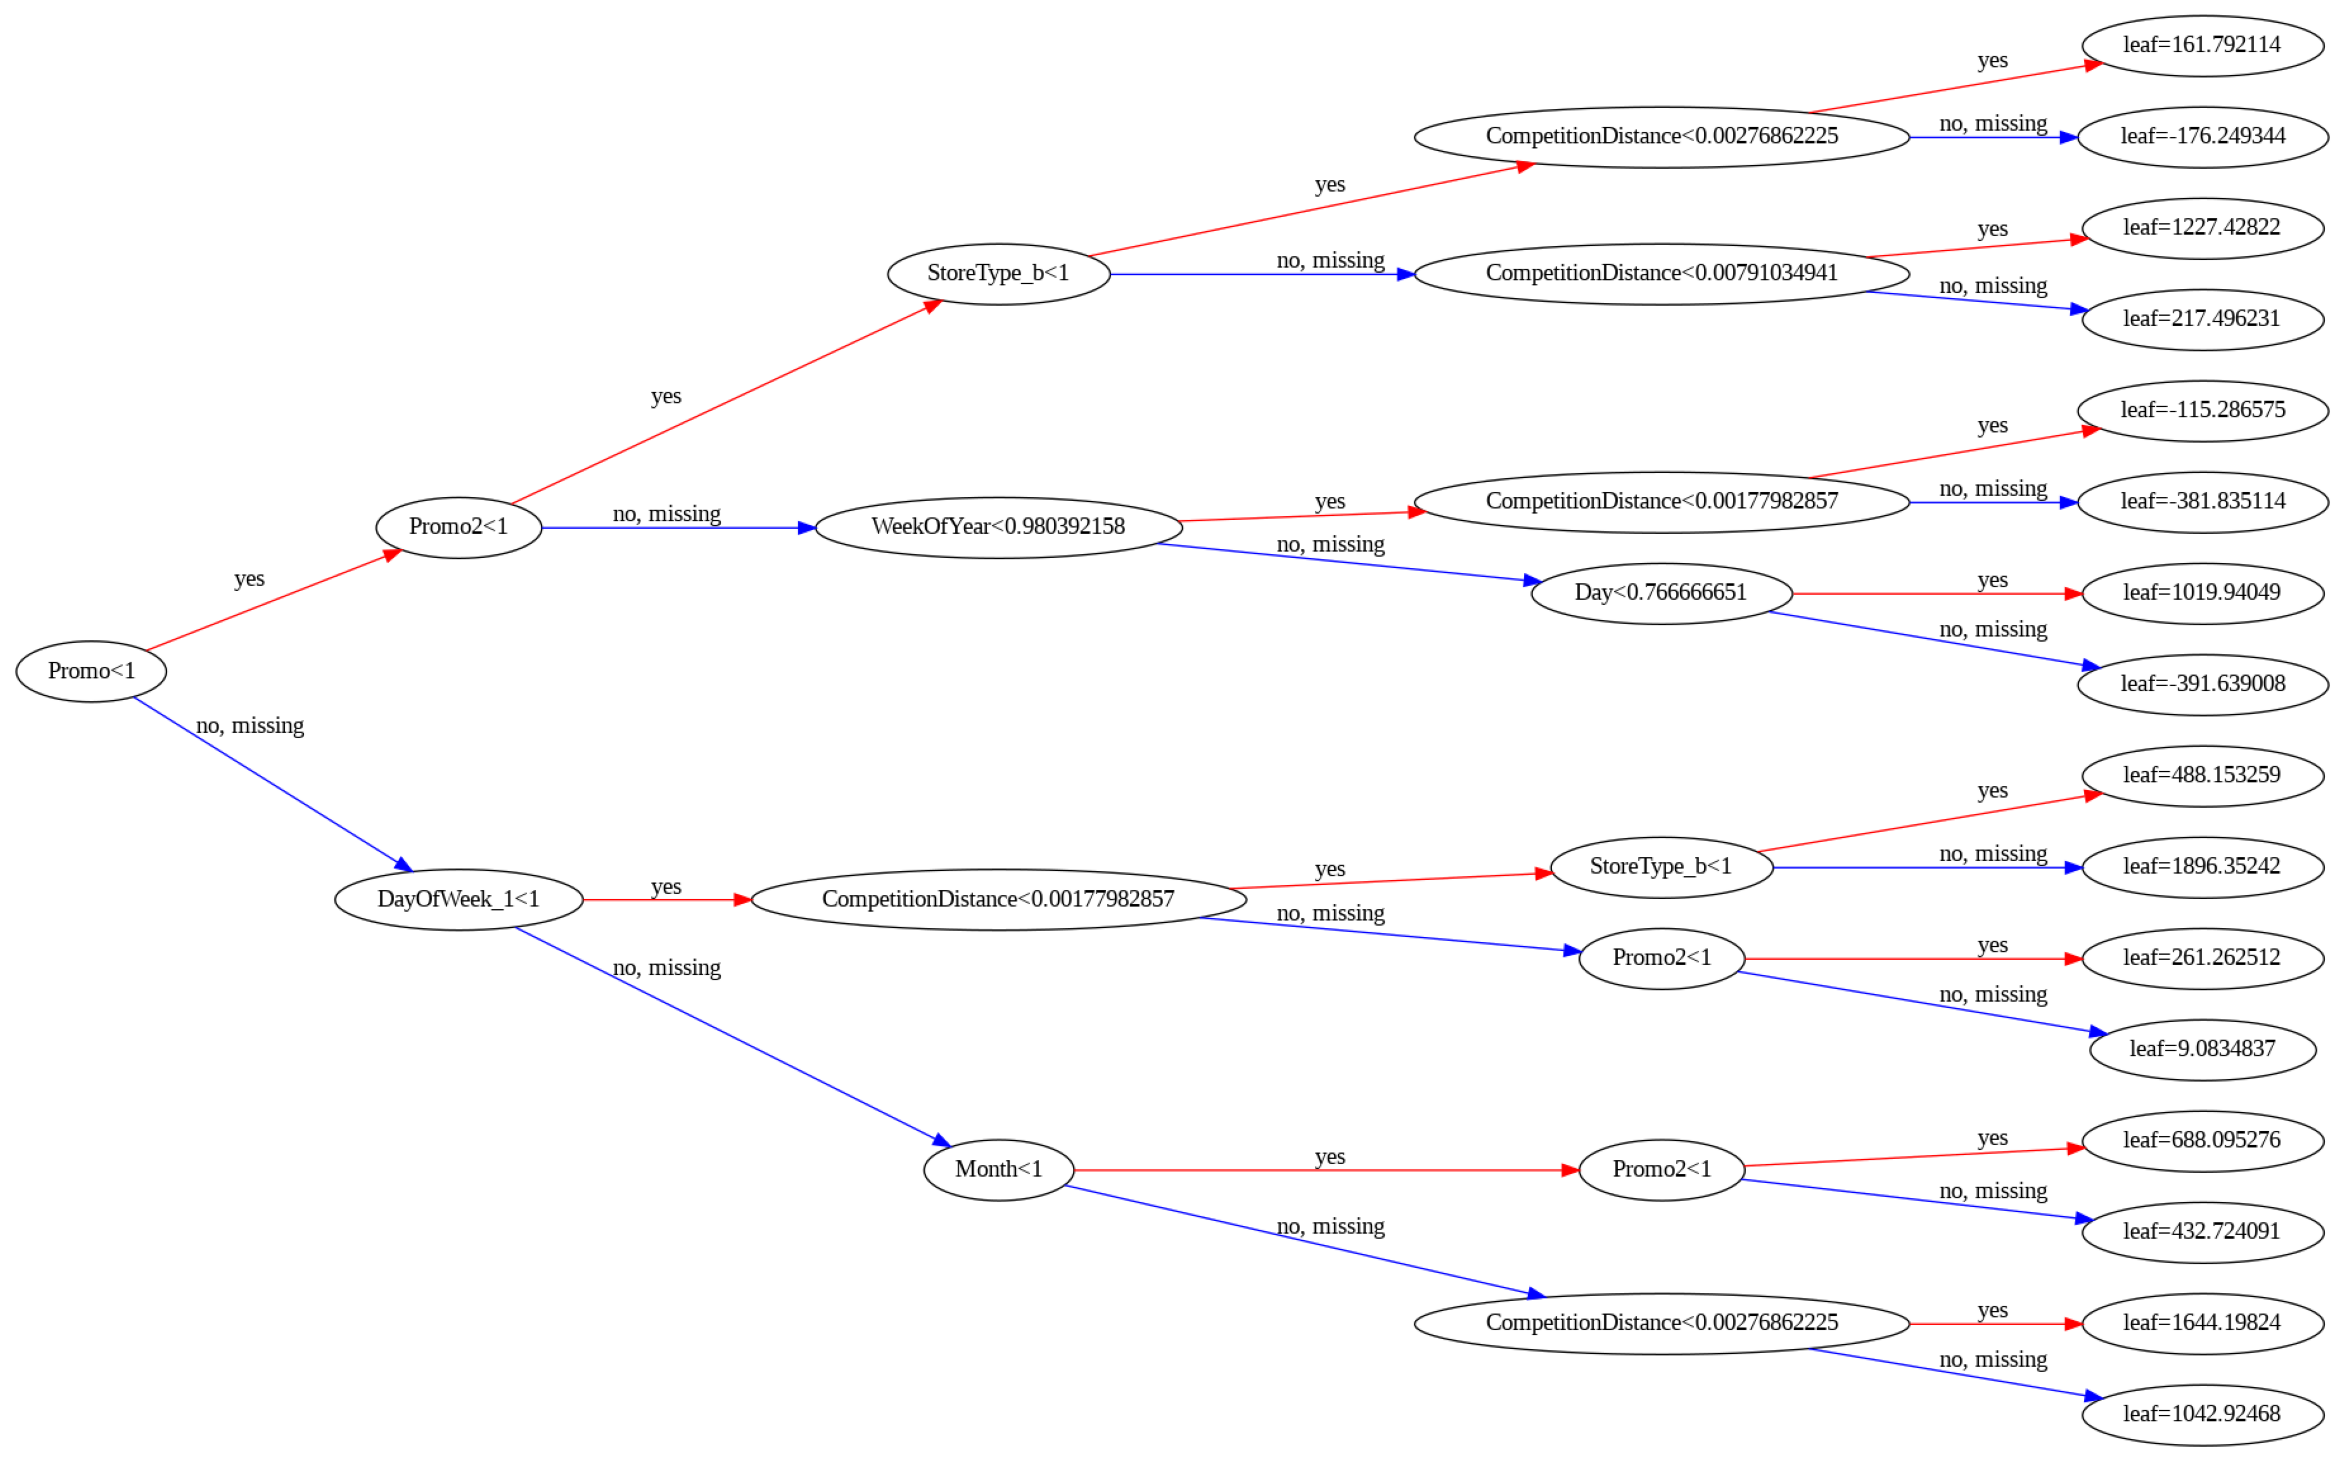

In [60]:
plot_tree(model,rankdir='LR',num_trees=1)

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

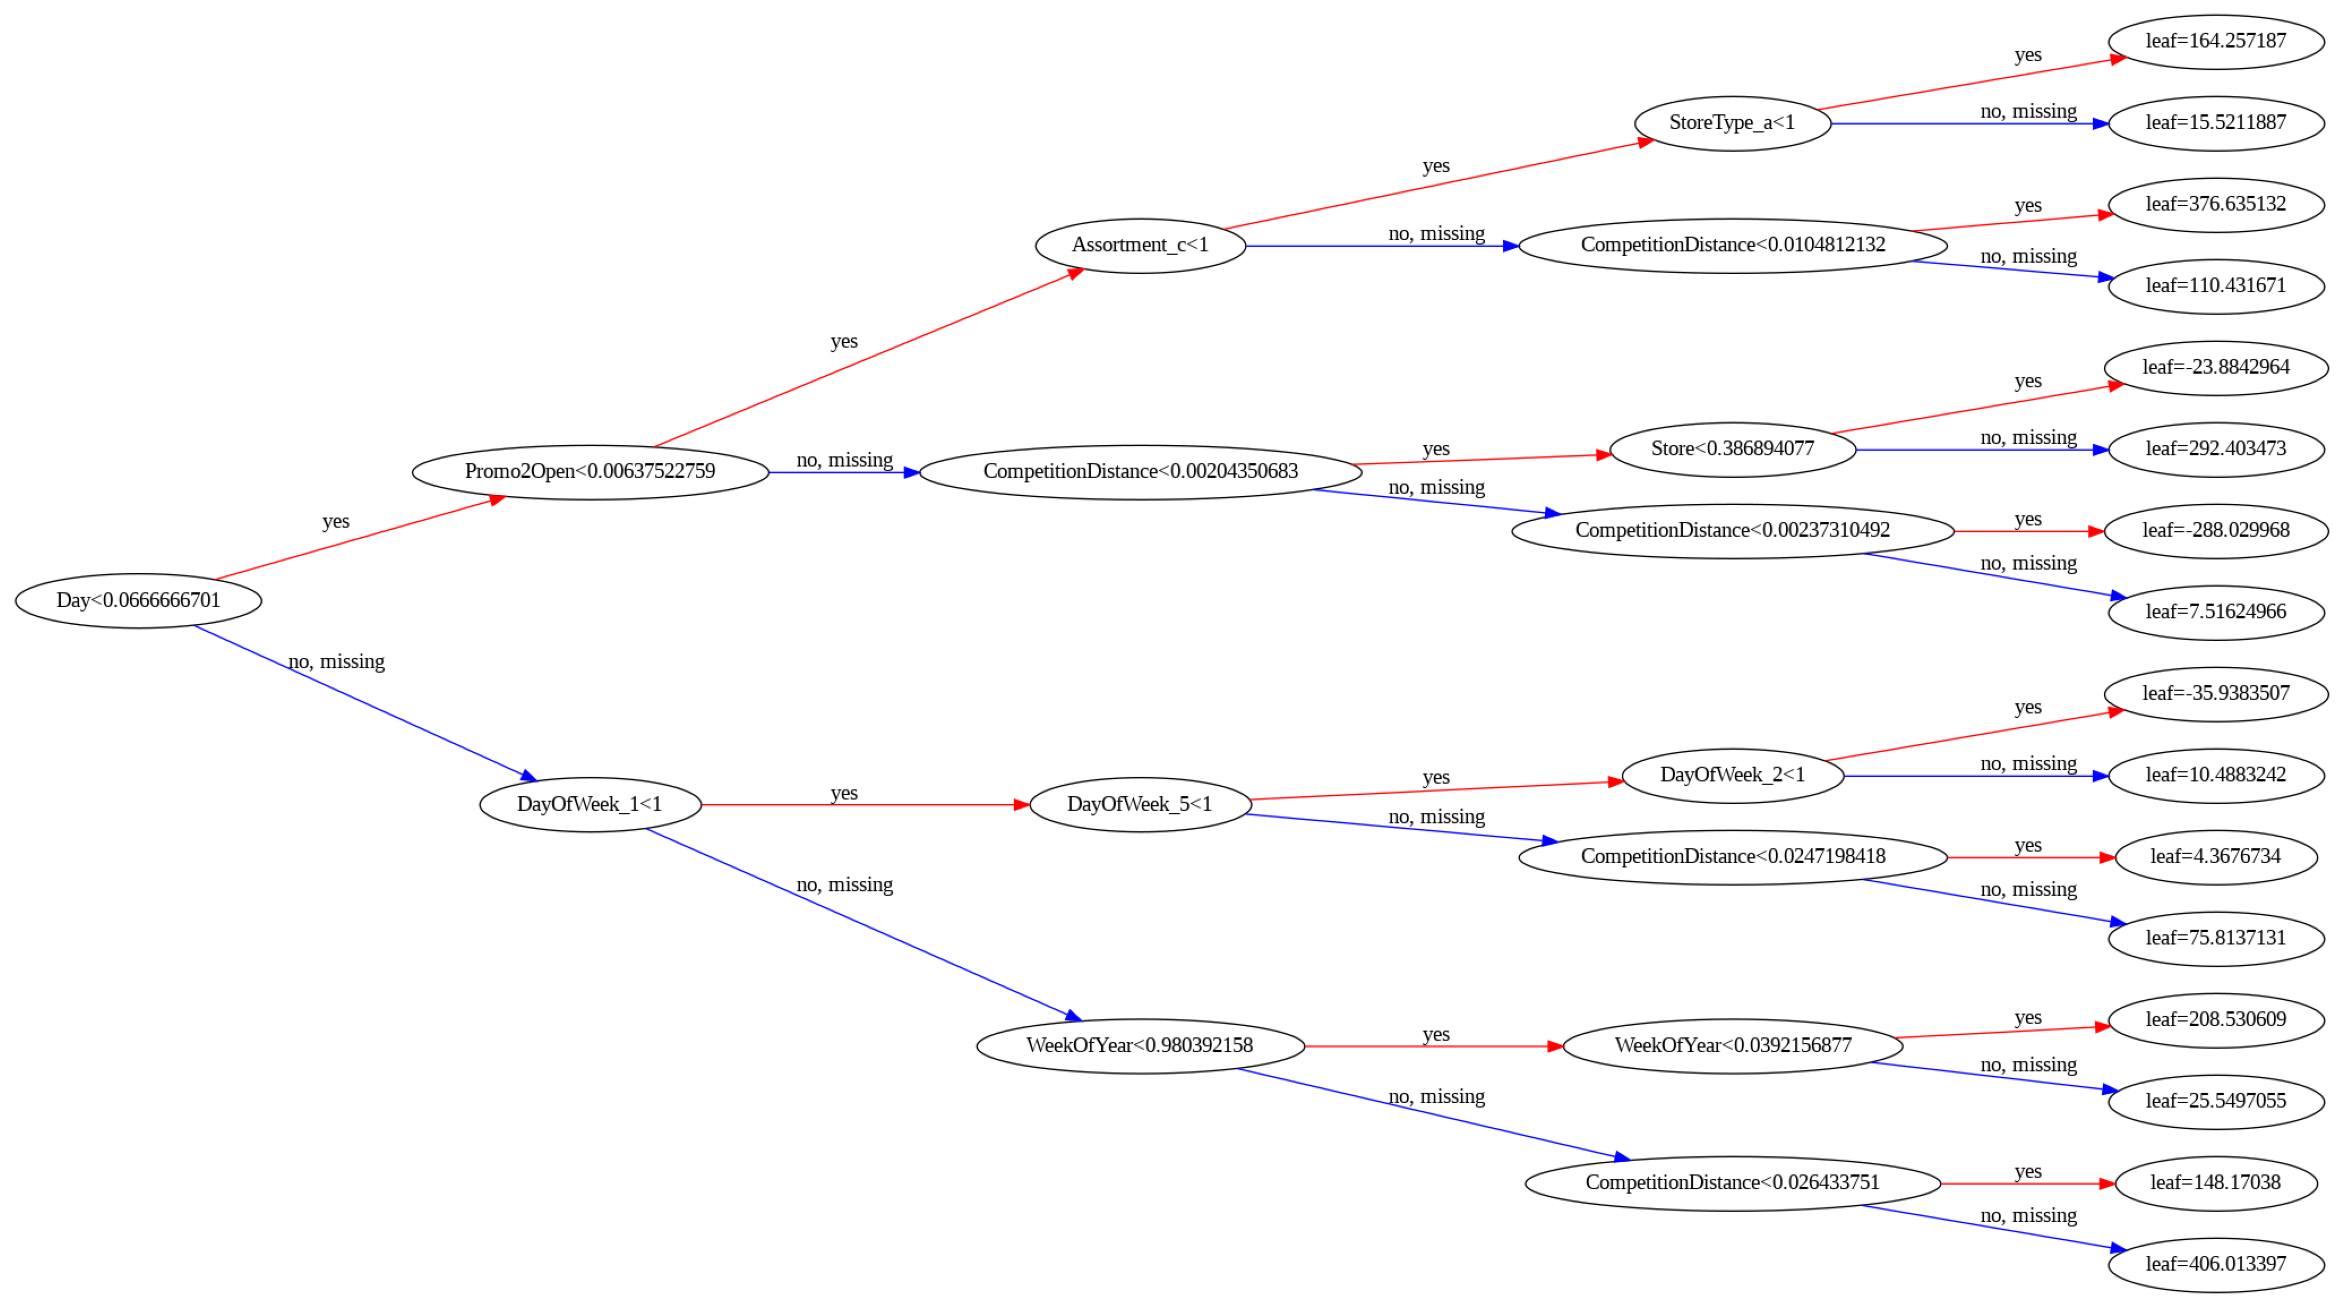

In [61]:
plot_tree(model,rankdir='LR',num_trees=19)

In [62]:
trees = model.get_booster().get_dump()

In [63]:
len(trees)

20

In [64]:
print(trees[0])

0:[Promo<1] yes=1,no=2,missing=2
	1:[StoreType_b<1] yes=3,no=4,missing=4
		3:[Assortment_a<1] yes=7,no=8,missing=8
			7:[CompetitionDistance<0.0023071852] yes=15,no=16,missing=16
				15:leaf=181.975769
				16:leaf=-259.831238
			8:[WeekOfYear<0.921568632] yes=17,no=18,missing=18
				17:leaf=-467.055237
				18:leaf=-83.930191
		4:[CompetitionDistance<0.00791034941] yes=9,no=10,missing=10
			9:[CompetitionDistance<0.00593276182] yes=19,no=20,missing=20
				19:leaf=654.354065
				20:leaf=3492.14575
			10:[DayOfWeek_7<1] yes=21,no=22,missing=22
				21:leaf=-187.357132
				22:leaf=877.194702
	2:[DayOfWeek_1<1] yes=5,no=6,missing=6
		5:[Month<1] yes=11,no=12,missing=12
			11:[StoreType_b<1] yes=23,no=24,missing=24
				23:leaf=208.808884
				24:leaf=1208.23828
			12:[Day<0.200000003] yes=25,no=26,missing=26
				25:leaf=668.335449
				26:leaf=1160.14038
		6:[Month<1] yes=13,no=14,missing=14
			13:[CompetitionDistance<0.00138431112] yes=27,no=28,missing=28
				27:leaf=1261.60889
				28:leaf=752

### Feature Importance

In [65]:
model.feature_importances_

array([0.02527164, 0.31209123, 0.0282055 , 0.03720191, 0.05450109,
       0.02481893, 0.0300427 , 0.00981984, 0.02833696, 0.03689261,
       0.02381629, 0.00587059, 0.0721726 , 0.01458464, 0.00414689,
       0.        , 0.0153004 , 0.00701009, 0.02038252, 0.        ,
       0.        , 0.        , 0.        , 0.0150438 , 0.07617175,
       0.0085583 , 0.08578162, 0.0459926 , 0.        , 0.01798557],
      dtype=float32)

In [66]:
X.columns

Index(['Store', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2',
       'Day', 'Month', 'Year', 'WeekOfYear', 'CompetitionOpen', 'Promo2Open',
       'IsPromo2Month', 'DayOfWeek_1', 'DayOfWeek_2', 'DayOfWeek_3',
       'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6', 'DayOfWeek_7',
       'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c',
       'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d',
       'Assortment_a', 'Assortment_b', 'Assortment_c'],
      dtype='object')

In [67]:
importance_df = pd.DataFrame({
    'feature' : X.columns,
    'importance': model.feature_importances_
}).sort_values('importance',ascending=False)

In [68]:
importance_df.head(10)

,feature,importance
1,Promo,0.312091
26,StoreType_d,0.085782
24,StoreType_b,0.076172
12,DayOfWeek_1,0.072173
4,Promo2,0.054501
27,Assortment_a,0.045993
3,CompetitionDistance,0.037202
9,CompetitionOpen,0.036893
6,Month,0.030043
8,WeekOfYear,0.028337


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

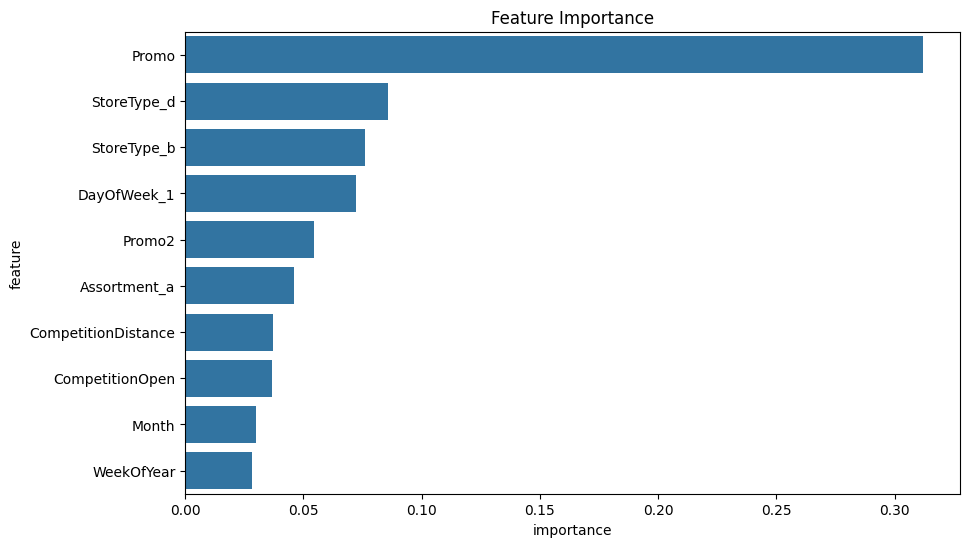

In [69]:
import seaborn as sns
plt.figure(figsize=(10,6))
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10),x='importance',y='feature')

### **K-Fold Cross Validation**

In [70]:
from sklearn.model_selection import KFold

In [71]:
def train_and_evaluate(X_train,train_target,X_val, val_target, **params):
  model = XGBRegressor(random_state = 42, n_jobs=-1, **params)
  model.fit(X_train,train_target)
  train_rmse = (model.predict(X_train),train_target)
  val_rmse = (model.predict(X_val), val_target)
  return model, train_rmse, val_rmse


In [72]:
kfold = KFold(n_splits=5, shuffle=True)

In [73]:
models = []

for train_idxs, val_idxs in kfold.split(X):
  X_train, train_target = X.iloc[train_idxs],targets.iloc[train_idxs]
  X_val, val_target = X.iloc[val_idxs],targets.iloc[val_idxs]
  model, train_rmse, val_rmse = train_and_evaluate(X_train,train_target,X_val,val_target, max_depth = 4,n_estimators=10)
  models.append(model)
  print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse, val_rmse))

Train RMSE: (array([ 7797.806 ,  7460.853 ,  7684.712 , ..., 11840.239 ,  6563.5776,
        8163.7334], dtype=float32),          Sales
0         5263
1         6064
2         8314
3        13995
4         4822
...        ...
1016656   8498
1016776   3375
1016827  10765
1016863   5035
1017042   4491

[675513 rows x 1 columns]), Validation RMSE: (array([8204.507 , 7460.853 , 8204.507 , ..., 6869.0747, 8163.7334,
       9926.159 ], dtype=float32),          Sales
10       10457
13        6544
20        9515
22        7273
23       14190
...        ...
1016356  17267
1016429   2401
1016606   2646
1016770   3821
1017190   5961

[168879 rows x 1 columns])
Train RMSE: (array([8093.9077, 7581.229 , 8220.523 , ..., 9698.704 , 7844.995 ,
       9698.704 ], dtype=float32),          Sales
0         5263
1         6064
2         8314
3        13995
7         8492
...        ...
1016770   3821
1016776   3375
1016827  10765
1017042   4491
1017190   5961

[675513 rows x 1 columns]), Validation RMSE: (

In [74]:
import numpy as np

def predict_avg(models, inputs):
  return np.mean([model.predict(inputs) for model in models], axis=0)

In [75]:
preds = predict_avg(models, X)
preds

array([ 8064.233 ,  7664.3516,  8013.143 , ...,  6958.603 ,  8008.0986,
       10106.232 ], dtype=float32)

In [76]:
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10,
             n_jobs=-1, num_parallel_tree=None, ...)

In [77]:
def test_params_kflod(n_splits, **params):
  train_rmses, val_rmses, models = [], [], []
  kfold = KFold(n_splits)
  for train_idxs, val_idxs in kfold.split(X):
    X_train, train_target = X.iloc[train_idxs],targets.iloc[train_idxs]
    X_val, val_target = X.iloc[val_idxs],targets.iloc[val_idxs]
    model, train_rmse, val_rmse = train_and_evaluate(X_train,train_target,X_val,val_target, max_depth = 4,n_estimators=10)
    models.append(model)
    train_rmses.append(train_rmse)
    val_rmses.append(val_rmse)
    print('Train RMSE: {}, Validation RMSE: {}'.format(np.mean(train_rmses), np.mean(val_rmse)))
    return models

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_val, train_target, val_target = train_test_split(X, targets, test_size = 0.1)

In [79]:
def test_params(**params):
  model = XGBRegressor(n_jobs=-1,random_state=42, **params)
  model.fit(X_train, train_target)
  train_rmse = rmse(model.predict(X_train),train_target)
  val_rmse = rmse(model.predict(X_val),val_target)
  print('Train RMSE: {}, Validation RMSE: {}'.format(train_rmse,val_rmse))


In [80]:
test_params(n_estimators=20)

Train RMSE: 2084.699738571481, Validation RMSE: 2104.4932881812665


In [81]:
test_params(n_estimators=35)

Train RMSE: 1783.2282523558222, Validation RMSE: 1802.6596323210879


In [82]:
test_params(n_estimators=50)

Train RMSE: 1569.324456573592, Validation RMSE: 1587.637159429068


In [83]:
test_params(max_depth=3,n_estimators=15)

Train RMSE: 2553.8209608349603, Validation RMSE: 2570.572309817407


In [84]:
test_params(max_depth=10,n_estimators=15)

Train RMSE: 1484.2397885786515, Validation RMSE: 1525.5593236580478


In [85]:
test_params(n_estimators = 40, learning_rate = 0.01)

Train RMSE: 2831.986846720867, Validation RMSE: 2845.4056828508656


In [86]:
test_params(n_estimators = 40, learning_rate = 0.1)

Train RMSE: 2262.700156892203, Validation RMSE: 2280.315000169933


In [87]:
test_params(n_estimators = 40, learning_rate = 0.9)

Train RMSE: 1199.0348201782965, Validation RMSE: 1221.3443924626665


In [88]:
test_params(n_estimators = 40, learning_rate = 0.95, max_depth = 15)

Train RMSE: 330.24705477490636, Validation RMSE: 1022.9265002921765


In [89]:
test_params(booster = 'gblinear')

Train RMSE: 2726.0442953114316, Validation RMSE: 2741.9793033500455


In [90]:
model = XGBRegressor(n_jobs=-1, random_state=42, n_estimators=100,learning_rate=0.95, max_depth=12,subsample=0.9,colsample_bytree=0.8)

In [91]:
model.fit(X,targets)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.95, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [92]:
X_test

,Store,Promo,SchoolHoliday,CompetitionDistance,Promo2,Day,Month,Year,WeekOfYear,CompetitionOpen,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
0,0.000000,1.0,0.0,0.008240,0.0,0.533333,0.727273,1.0,0.725490,0.060606,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.001795,1.0,0.0,0.093013,1.0,0.533333,0.727273,1.0,0.725490,0.075758,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.005386,1.0,0.0,0.158075,0.0,0.533333,0.727273,1.0,0.725490,0.020924,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.006284,1.0,0.0,0.049440,0.0,0.533333,0.727273,1.0,0.725490,0.007937,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.007181,1.0,0.0,0.013250,0.0,0.533333,0.727273,1.0,0.725490,0.130592,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,0.996409,0.0,0.0,0.012393,1.0,0.000000,0.636364,1.0,0.588235,0.010101,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
41084,0.997307,0.0,0.0,0.012261,0.0,0.000000,0.636364,1.0,0.588235,0.080808,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
41085,0.998205,0.0,0.0,0.060910,0.0,0.000000,0.636364,1.0,0.588235,0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
41086,0.999102,0.0,0.0,0.005603,0.0,0.000000,0.636364,1.0,0.588235,0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [93]:
test_preds = model.predict(X_test)

In [94]:
test_preds

array([ 4270.6997,  7790.075 ,  7944.6025, ...,  7465.554 , 22851.305 ,
        7370.3755], dtype=float32)

In [95]:
submission_df = pd.read_csv('/content/sample_submission.csv')

In [96]:
submission_df['Sales'] = test_preds

In [97]:
test_df.Open.isna().sum()

np.int64(11)

In [98]:
submission_df

,Id,Sales
0,1,4270.699707
1,2,7790.075195
2,3,7944.602539
3,4,6584.373047
4,5,7841.320801
...,...,...
41083,41084,3256.438477
41084,41085,6805.440918
41085,41086,7465.554199
41086,41087,22851.304688


In [99]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [100]:
submission_df['Sales'] = submission_df['Sales'] * test_df.Open.fillna(1.)

In [101]:
submission_df['Sales']

,Sales
0,4270.699707
1,7790.075195
2,7944.602539
3,6584.373047
4,7841.320801
...,...
41083,3256.438477
41084,6805.440918
41085,7465.554199
41086,22851.304688


In [102]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [117]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [118]:
sample_input = {
    'Store': 2,
    'DayOfWeek': 4,
    'Promo': 1,
    'Date': '2015-07-25',
    'Open': 1,
    'StateHoliday': 'a',
    'SchoolHoliday': 0,
}

In [119]:
input_df = pd.DataFrame([sample_input])
input_df

,Store,DayOfWeek,Promo,Date,Open,StateHoliday,SchoolHoliday
0,2,4,1,2015-07-25,1,a,0


In [120]:
input_merged_df = input_df.merge(store_df, on = 'Store')
input_merged_df

,Store,DayOfWeek,Promo,Date,Open,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,2,4,1,2015-07-25,1,a,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"


In [121]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [122]:
split_date(input_merged_df)
comp_months(input_merged_df)
promo_cols(input_merged_df)
input_merged_df

,Store,DayOfWeek,Promo,Date,Open,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year,WeekOfYear,CompetitionOpen,Promo2Open,IsPromo2Month
0,2,4,1,2015-07-25,1,a,0,a,a,570.0,...,13.0,2010.0,"Jan,Apr,Jul,Oct",25,7,2015,30,92.0,63.901639,1


In [123]:
input_merged_df[numeric_cols] = scaler.transform(input_merged_df[numeric_cols])
input_merged_df[encoded_cols] = encoder.transform(input_merged_df[categorial_cols])

In [124]:
X_input = input_merged_df[numeric_cols + encoded_cols]
model.predict(X_input)[0]

np.float32(6358.4077)

In [125]:
sample_input

{'Store': 2,
 'DayOfWeek': 4,
 'Promo': 1,
 'Date': '2015-07-25',
 'Open': 1,
 'StateHoliday': 'a',
 'SchoolHoliday': 0}